**Programming Assignment 2 CNN and data competition**

**Import tenserflow**

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt

IMG_SIZE      = (32, 32)
RESIZE_TO     = (128, 128)
BATCH_SIZE    = 128
AUTOTUNE      = tf.data.AUTOTUNE
NUM_CLASSES   = 100
WARMUP_EPOCHS = 10
TOTAL_EPOCHS  = 150

**Load and Visualize the sample (cifar 100)**

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Train: 45000  |  Val: 5000  |  Test: 10000


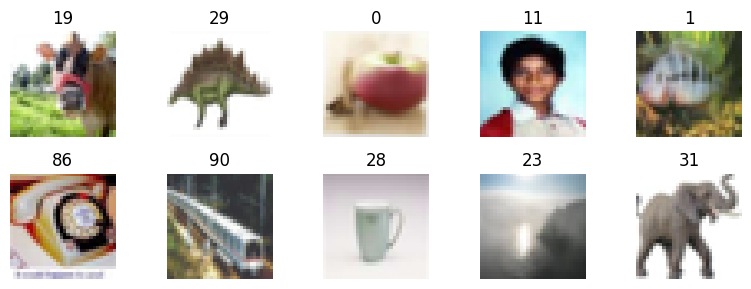

In [2]:
(x_tr_full, y_tr_full), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()

val_size  = int(len(x_tr_full) * 0.1)
x_val,  y_val  = x_tr_full[:val_size],  y_tr_full[:val_size]
x_tr,   y_tr   = x_tr_full[val_size:],  y_tr_full[val_size:]

y_tr   = y_tr.flatten()
y_val  = y_val.flatten()
y_test = y_test.flatten()

print(f"Train: {len(x_tr)}  |  Val: {len(x_val)}  |  Test: {len(x_test)}")

plt.figure(figsize=(8, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_tr_full[i])
    plt.title(int(y_tr_full[i][0]))
    plt.axis("off")
plt.tight_layout()
plt.show()

**Necessary Functions**

In [ ]:
def preprocess(image, label):
    image = tf.image.resize(image, RESIZE_TO)
    image = tf.keras.applications.efficientnet_v2.preprocess_input(image)
    return image, label

#data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
], name="data_aug")

class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, total_steps, warmup_steps):
        super().__init__()
        self.base_lr      = base_lr
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)
        self.cosine       = tf.keras.optimizers.schedules.CosineDecay(
            base_lr, total_steps - warmup_steps, alpha=1e-2
        )

    def __call__(self, step):
        step      = tf.cast(step, tf.float32)
        warmup_lr = self.base_lr * (step / self.warmup_steps)
        cosine_lr = self.cosine(step - self.warmup_steps)
        return tf.cond(step < self.warmup_steps, lambda: warmup_lr, lambda: cosine_lr)

    def get_config(self):
        return {"base_lr": self.base_lr, "warmup_steps": int(self.warmup_steps.numpy())}

train_ds = (
    tf.data.Dataset.from_tensor_slices((x_tr, y_tr))
    .shuffle(len(x_tr))
    .batch(BATCH_SIZE, drop_remainder=True)
    .map(lambda x, y: preprocess(data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((x_val, y_val))
    .batch(BATCH_SIZE)
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test))
    .batch(BATCH_SIZE)
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

#callbacks
early_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=20, restore_best_weights=True, verbose=1
)

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1
)

#lr_schedule
steps_per_epoch = int(np.ceil(len(x_tr) / BATCH_SIZE))
head_lr_schedule = WarmupCosineDecay(
    base_lr      = 1e-3,
    total_steps  = steps_per_epoch * WARMUP_EPOCHS,
    warmup_steps = steps_per_epoch * 2,
)
fine_tune_lr_schedule = WarmupCosineDecay(
    base_lr      = 1e-4,
    total_steps  = steps_per_epoch * TOTAL_EPOCHS,
    warmup_steps = steps_per_epoch * WARMUP_EPOCHS,
)

#normalization
mean = np.mean(x_tr, axis=(0, 1, 2), keepdims=True) / 255.0
std  = np.std(x_tr,  axis=(0, 1, 2), keepdims=True) / 255.0
normalizer = tf.keras.Sequential([
    layers.Rescaling(1.0 / 255),
    layers.Normalization(mean=mean, variance=std ** 2),
], name="normalizer")

**Construct CNN**

In [ ]:
CNN_model = models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    data_augmentation,
    layers.Rescaling(1./255),
    layers.Normalization(mean=mean, variance=std**2),

    layers.Conv2D(64, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(64, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.20),

    layers.Conv2D(128, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(128, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(256, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(256, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.30),

    layers.Conv2D(512, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(512, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.35),

    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(5e-4)),
    layers.Dropout(0.45),
    layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(5e-4)),
    layers.Dropout(0.35),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

CNN_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

CNN_model.summary()

print("\nBASELINE CNN: Training from scratch")
CNN_history = CNN_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_cb],
    verbose=1
)

CNN_val_loss, CNN_val_acc = CNN_model.evaluate(val_ds, verbose=0)
print(f"\nBaseline VAL Accuracy: {CNN_val_acc:.4f} | VAL Loss: {CNN_val_loss:.4f}")

**Construct Efficient Net + CNN**

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 4, 4, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,043,652 (80.28 MB)

 Trainable params: 709,732 (2.71 MB)

 Non-trainable params: 20,333,920 (77.57 MB)

Phase 1: Training head with frozen backbone
Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 105s 114ms/step - accuracy: 0.0528 - loss: 5.2249 - val_accuracy: 0.5162 - val_loss: 2.0678
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.3243 - loss: 2.8963 - val_accuracy: 0.5974 - val_loss: 1.5684
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.3891 - loss: 2.5095 - val_accuracy: 0.6200 - val_loss: 1.4736
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.4237 - loss: 2.3452 - val_accuracy: 0.6320 - val_loss: 1.4418
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.4369 - loss: 2.2463 - val_accuracy: 0.6362 - val_loss: 1.3966
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.4576 - loss: 2.1590 - val_accuracy: 0.6444 - val_loss: 1.3746
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.4642 - loss: 2.1075 - val_accuracy: 0.6444 - val_loss: 1.3584
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 

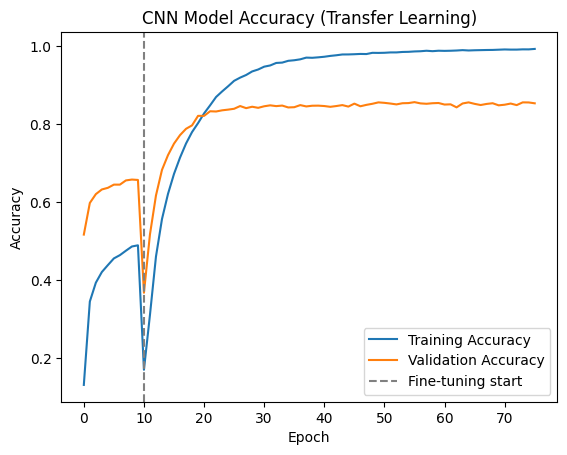


Final Test Accuracy: 0.8560 | Test Loss: 0.8093


In [4]:
efficient_net_model = tf.keras.applications.EfficientNetV2S(
    input_shape=RESIZE_TO + (3,),
    include_top=False,
    weights="imagenet",
)
efficient_net_model.trainable = False

inputs  = layers.Input(shape=RESIZE_TO + (3,))
x       = efficient_net_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

improved_cnn_model = tf.keras.Model(inputs, outputs)
improved_cnn_model.summary()

improved_cnn_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=head_lr_schedule),
    loss      = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics   = ["accuracy"],
)

print("Phase 1: Training head with frozen backbone")
improved_cnn_history_phase1 = improved_cnn_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = WARMUP_EPOCHS,
    verbose         = 1,
)
efficient_net_model.trainable = True

improved_cnn_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=fine_tune_lr_schedule),
    loss      = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics   = ["accuracy"],
)

print("\nnPhase 2: Fine-tuning full model")
improved_cnn_history_phase2 = improved_cnn_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = TOTAL_EPOCHS,
    callbacks       = [early_cb, checkpoint_cb],
    verbose         = 1,
)

val_loss, val_acc = improved_cnn_model.evaluate(val_ds, verbose=0)
print(f"\nEfficientNet VAL Accuracy: {val_acc:.4f} | Test Loss: {val_loss:.4f}")

**Visualize Comparison**

In [ ]:
#CNN curves
b_acc = CNN_history.history["accuracy"]
b_val = CNN_history.history["val_accuracy"]

#efficientNet curves
p1_acc = improved_cnn_history_phase1.history["accuracy"]
p2_acc = improved_cnn_history_phase2.history["accuracy"]
p1_val = improved_cnn_history_phase1.history["val_accuracy"]
p2_val = improved_cnn_history_phase2.history["val_accuracy"]

eff_acc = p1_acc + p2_acc
eff_val = p1_val + p2_val
split = len(p1_acc)

plt.plot(b_acc, label="Baseline Train Acc")
plt.plot(b_val, label="Baseline Val Acc")
plt.plot(eff_acc, label="EffNet Train Acc")
plt.plot(eff_val, label="EffNet Val Acc")
plt.axvline(x=split, color="gray", linestyle="--", label="EffNet fine-tune start")
plt.title("Accuracy: Baseline CNN vs EfficientNet Transfer Learning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**CNN Prediction (Cifar100)**

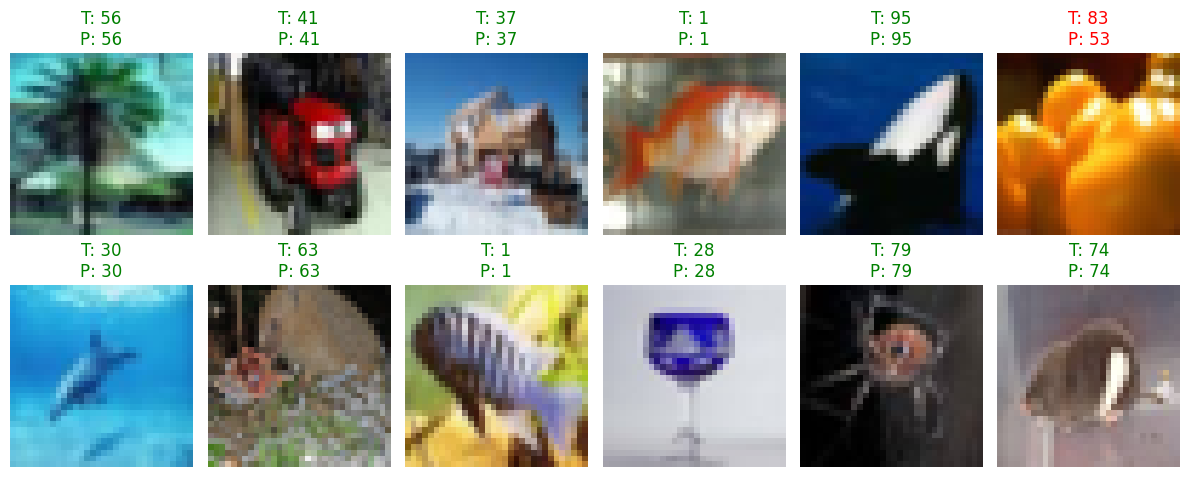

In [ ]:
class PredictionViewer:
    def __init__(self, model, resize_to=(128, 128)):
        self.model = model
        self.resize_to = resize_to

    def preprocess(self, img):
        img = tf.image.resize(img, self.resize_to)
        img = tf.keras.applications.efficientnet_v2.preprocess_input(img)
        return img

    def show_predictions(self, images, labels, num_images=10):
        indices = np.random.choice(len(images), num_images, replace=False)

        plt.figure(figsize=(12, 5))

        for i, idx in enumerate(indices):
            img = images[idx]
            true_label = int(labels[idx])

            img_processed = self.preprocess(img)
            pred = self.model.predict(
                tf.expand_dims(img_processed, axis=0),
                verbose=0
            )
            pred_label = np.argmax(pred)

            plt.subplot(2, int(np.ceil(num_images / 2)), i + 1)
            plt.imshow(img.astype("uint8"))
            plt.title(
                f"T: {true_label}\nP: {pred_label}",
                color="green" if true_label == pred_label else "red"
            )
            plt.axis("off")

        plt.tight_layout()
        plt.show()

viewer = PredictionViewer(CNN_model, resize_to=RESIZE_TO)
viewer.show_predictions(x_test, y_test, num_images=12)

**EfficientNet CNN Prediction(Cifar100)**

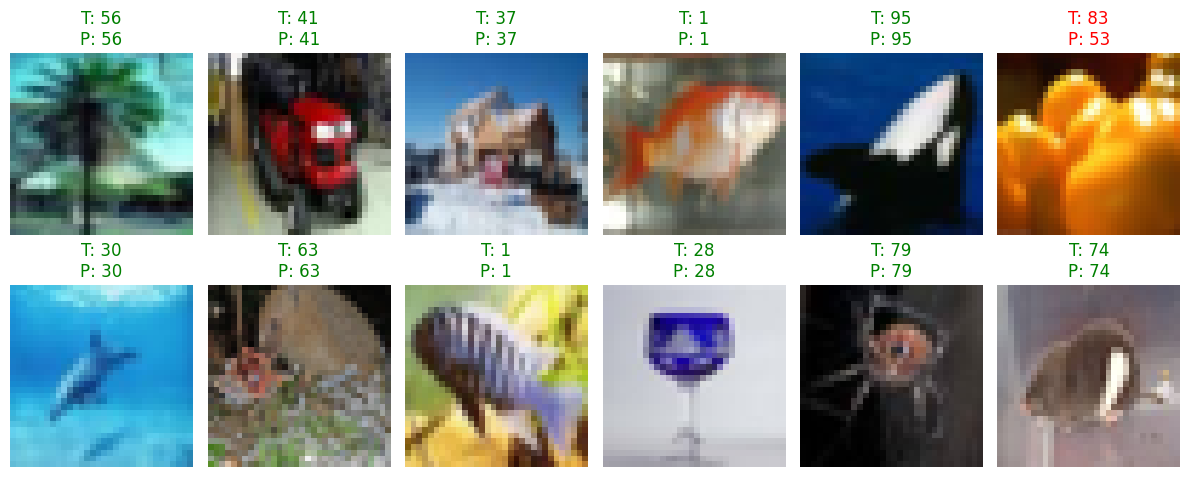

In [ ]:
viewer = PredictionViewer(improved_cnn_model, resize_to=RESIZE_TO)
viewer.show_predictions(x_test, y_test, num_images=12)